In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numba import jit
from scipy import stats
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d


@jit(nopython=True)
def RK4_ZZ(f, y0, t, args=()):
    n = len(t)
    y = np.zeros((n, len(y0)))
    Etheta = np.exp(1j*y0)
    Na = args[0]
    EA,EB = Etheta[:Na],Etheta[Na:]
    Z1a,Z2a = get_ZE12(EA)
    Z1b,Z2b = get_ZE12(EB)
    Z1as = np.zeros(n,dtype=np.complex64)
    Z1bs = np.zeros(n,dtype=np.complex64)
    Z2as = np.zeros(n,dtype=np.complex64)
    Z2bs = np.zeros(n,dtype=np.complex64)

    Z1as[0] = Z1a
    Z2as[0] = Z2a
    Z1bs[0] = Z1b
    Z2bs[0] = Z2b
    
    y[0] = y0
    
    for i in range(n - 1):
        h = t[i + 1] - t[i]
        k1,Z1a,Z1b,Z2a,Z2b = f(y[i], t[i], *args)
        k2,_,_,_,_ = f(y[i] + k1 * h / 2.0, t[i] + h / 2.0, *args)
        k3,_,_,_,_ = f(y[i] + k2 * h / 2.0, t[i] + h / 2.0, *args)
        k4,_,_,_,_ = f(y[i] + k3 * h, t[i] + h, *args)
        y[i + 1] = y[i] + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        Z1as[i+1],Z1bs[i+1],Z2as[i+1],Z2bs[i+1] = Z1a,Z1b,Z2a,Z2b
    return y,(Z1as,Z1bs,Z2as,Z2bs)

@jit(nopython=True)
def RK4_ZZ2(f, y0, t, args=()):
    n = len(t)
    Etheta = np.exp(1j*y0)
    Na = args[0]
    EA,EB = Etheta[:Na],Etheta[Na:]
    Z1a,Z2a = get_ZE12(EA)
    Z1b,Z2b = get_ZE12(EB)
    Z1as = np.zeros(n,dtype=np.complex64)
    Z1bs = np.zeros(n,dtype=np.complex64)
    Z2as = np.zeros(n,dtype=np.complex64)
    Z2bs = np.zeros(n,dtype=np.complex64)

    Z1as[0] = Z1a
    Z2as[0] = Z2a
    Z1bs[0] = Z1b
    Z2bs[0] = Z2b
    
    y = y0
    
    for i in range(n - 1):
        h = t[i + 1] - t[i]
        k1,Z1a,Z1b,Z2a,Z2b = f(y, t[i], *args)
        k2,_,_,_,_ = f(y + k1 * h / 2.0, t[i] + h / 2.0, *args)
        k3,_,_,_,_ = f(y + k2 * h / 2.0, t[i] + h / 2.0, *args)
        k4,_,_,_,_ = f(y + k3 * h, t[i] + h, *args)
        y = y + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        Z1as[i+1],Z1bs[i+1],Z2as[i+1],Z2bs[i+1] = Z1a,Z1b,Z2a,Z2b
    return Z1as,Z1bs,Z2as,Z2bs

@jit(nopython=True)
def get_ZE12(Etheta):
    ''' get theta and return r and theta'''
    E1 = Etheta
    E2 = E1**2
    Z1,Z2 = np.mean(E1),np.mean(E2)
    return Z1,Z2

# @jit(nopython=True)
# def Kuramoto_MF_CHIMERA(Theta,t,Na,Nb,beta,alpha,K):
#     dtheta = np.zeros(Na+Nb)

#     Etheta = np.exp(1j*Theta)
#     EA,EB = Etheta[:Na],Etheta`[Na:]
#     Z1a,Z2a = get_ZE12(EA)
#     Z1b,Z2b = get_ZE12(EB)
#     A = np.exp(-1j*alpha)
#     EA,EB = np.conjugate(EA), np.conjugate(EB)
#     ZZa =  (Z1a+beta*Z1b)
#     ZZb =  (Z1b+beta*Z1a)
#     dtheta[:Na] = K*((A*(ZZa**2-Z2a/Na - beta*Z2b/Nb))*EA*EA -(2*A/Na*ZZa)*EA).imag
#     dtheta[Na:] = K*((A*(ZZb**2-Z2b/Nb - beta*Z2a/Na))*EB*EB -(2*A/Nb*ZZb)*EB).imag
#     return dtheta,Z1a,Z1b,Z2a,Z2b

@jit(nopython=True)
def Kuramoto_MF_CHIMERA(Theta,t,Na,Nb,beta,alpha,K):
    dtheta = np.zeros(Na+Nb)

    Etheta = np.exp(1j*Theta)
    EA,EB = Etheta[:Na],Etheta[Na:]
    Z1a,Z2a = get_ZE12(EA)
    Z1b,Z2b = get_ZE12(EB)
    A = np.exp(-1j*alpha)
    EA,EB = np.conjugate(EA), np.conjugate(EB)
    ZZa =  K*(Z1a+beta*Z1b)
    ZZb =  K*(Z1b+beta*Z1a)
    dtheta[:Na] = ((A*(ZZa**2))*EA*EA).imag
    dtheta[Na:] = ((A*(ZZb**2))*EB*EB).imag
    return dtheta,Z1a,Z1b,Z2a,Z2b



import functools
import numpy as np
from scipy.optimize import root_scalar


def _vectorize_float(f):
    vectorized = np.vectorize(f, otypes=[float], signature="(),()->()")

    @functools.wraps(f)
    def wrapper(*args):
        return vectorized(*args)

    return wrapper

def dist_ab(x, a, b, eta):
    a_ = a*np.exp(1j*x)/(1-a*np.exp(1j*x))
    b_ = b*np.exp(1j*x)/(1-b*np.exp(1j*x))
    f1 = 1/(2*np.pi) * (1+ (a_+a_.conjugate()))
    f2 = 1/(2*np.pi) * (1+ (b_+b_.conjugate()))
    f = (1+eta)/2 *f1+ (1-eta)/2 *f2
    return abs(f)


def gen_dist(N,a,b,eta,seed = None):
    x = np.linspace(-np.pi/2, 3*np.pi/2, 10000)
    pdf = dist_ab(x,a,b,eta)
    cdf = cumulative_trapezoid(pdf, x, initial=0)
    cdf /= cdf[-1]  # 정규화
    quantile_func = interp1d(cdf, x, kind='nearest', fill_value='extrapolate')
    if seed != None:
        np.random.seed(seed)
        ps = np.random.uniform(0,1,N)
    else:
        ps = (np.arange(N+1)[:-1] + 1)/(N+1)
    T = quantile_func(ps)
    return T



def gen_dist2(N,a,b,eta):
    xs = np.linspace(-np.pi/2, 3*np.pi/2, 10000)
    f_ab = dist_ab(xs,a,b,eta)
    f_ab /=np.sum(f_ab)
    u = np.linspace(0,1,N+2,endpoint=True)[1:-1]
    L = np.cumsum(f_ab)
    idx = np.searchsorted(L,u)
    return xs[idx]


def gen_dist_pert_r(N,Q,eps):
    xs = np.linspace(-np.pi/2, 3*np.pi/2, 10000)
    f_r = 1/(2*np.pi) * (1-Q**2) / (1-2*Q*np.cos(2*xs) + Q**2) + eps/(np.pi) * np.cos(xs)
    f_r /=np.sum(f_r)
    u = np.linspace(0,1,N+2,endpoint=True)[1:-1]
    L = np.cumsum(f_r)
    idx = np.searchsorted(L,u)
    return xs[idx]


def gen_dist_pert_q(N,Q,eps):
    xs = np.linspace(-np.pi/2, 3*np.pi/2, 10000)
    f_r = 1/(2*np.pi) * (1-Q**2) / (1-2*Q*np.cos(2*xs) + Q**2) - eps/(np.pi) * np.cos(2*xs)
    f_r /=np.sum(f_r)
    u = np.linspace(0,1,N+2,endpoint=True)[1:-1]
    L = np.cumsum(f_r)
    idx = np.searchsorted(L,u)
    return xs[idx]



class MixtureDistribution:
    def __init__(self, distributions, weights):
        self._distributions = list(distributions)
        self._weights = list(weights)

        if not (all(w >= 0 for w in self._weights) and sum(self._weights) == 1):
            raise ValueError("Invalid weight vector.")

        if len(self._distributions) != len(self._weights):
            raise ValueError("Mixtures and weights must have the same length.")

        if len(self._distributions) < 2:
            raise ValueError("Must have at least two component distributions.")

    @_vectorize_float
    def pdf(self, x):
        return sum(w * d.pdf(x) for w, d in zip(self._weights, self._distributions))

    @_vectorize_float
    def cdf(self, x):
        return sum(w * d.cdf(x) for w, d in zip(self._weights, self._distributions))

    @_vectorize_float
    def ppf(self, p):
        bracket = [min(dist.ppf(p) for dist in self._distributions),
                   max(dist.ppf(p) for dist in self._distributions)]

        r = root_scalar(
            f=lambda x: self.cdf(x) - p,
            fprime=self.pdf,
            bracket=bracket,
            x0=0
        )
        assert r.converged
        return r.root
    # https://www.jamesatkins.com/posts/quantile-function-of-mixture-distributions-in-python/



def get_m1_m2(N,eta1,eta2):
    ps = (np.arange(N+1)[:-1] + 1)/(N+1)

    sigma1 = 1e-10
    sigma2 = 0.50790452
    shift = 0*np.pi/8
    # m1 = MixtureDistribution([stats.norm(0,sigma1), stats.norm(np.pi,sigma1)], [1/2 + eta1/2, 1/2 - eta1/2])
    m2 = MixtureDistribution([stats.norm(0+shift,sigma2), stats.norm(np.pi+shift,sigma2)], [1/2 + eta2/2, 1/2 - eta2/2])
    Peak_0_N = int((1/2 *(1 + eta1))*N)
    Peak_pi_N = N - Peak_0_N
    theta1 = np.r_[np.zeros(Peak_0_N),np.pi*np.ones(Peak_pi_N)]
    theta2 = m2.ppf(ps)
    Q2_init = np.mean(np.exp(2j*theta2))
    print(abs(Q2_init),np.angle(Q2_init))
    # theta1 = m1.ppf(ps)
    Theta = np.r_[theta1,theta2]
    return Theta

@jit(nopython=True)
def RK4(f, y0, t, args=()):
    n = len(t)
    y = np.zeros((n,len(y0)))
    y[0] = y0

    for i in range(n - 1):
        h = t[i + 1] - t[i]
        k1 = f(y[i], t[i], *args)
        k2 = f(y[i] + k1 * h / 2.0, t[i] + h / 2.0, *args)
        k3 = f(y[i] + k2 * h / 2.0, t[i] + h / 2.0, *args)
        k4 = f(y[i] + k3 * h, t[i] + h, *args)
        y[i + 1] = y[i] + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    return y
# a1real,a1imag,b1real,b1imag,a2real,a2imag,b2real,b2imag
@jit(nopython=True)
def dZ_dt(Zs,t,alpha,beta,eta1,eta2):
    a1real,a1imag,b1real,b1imag,a2real,a2imag,b2real,b2imag = Zs
    a1 = a1real + 1j*a1imag
    a2 = a2real + 1j*a2imag
    b1 = b1real + 1j*b1imag
    b2 = b2real + 1j*b2imag
    Z11 = 1/2 * (np.conj(a1)+np.conj(b1)) + eta1/2 * (np.conj(a1)-np.conj(b1))
    Z12 = 1/2 * (np.conj(a2)+np.conj(b2)) + eta2/2 * (np.conj(a2)-np.conj(b2))
    H1 = (Z11**2 + 2*beta*Z11*Z12 + beta**2*Z12**2)
    H2 = (Z12**2 + 2*beta*Z11*Z12 + beta**2*Z11**2)
    
    da1 = 1/2 *(np.conj(H1)*np.conj(a1)*np.exp(1j*alpha) - H1*a1**3*np.exp(-1j*alpha) )
    db1 = 1/2 *(np.conj(H1)*np.conj(b1)*np.exp(1j*alpha) - H1*b1**3*np.exp(-1j*alpha) )
    da2 = 1/2 *(np.conj(H2)*np.conj(a2)*np.exp(1j*alpha) - H2*a2**3*np.exp(-1j*alpha) )
    db2 = 1/2 *(np.conj(H2)*np.conj(b2)*np.exp(1j*alpha) - H2*b2**3*np.exp(-1j*alpha) )
    return np.array([da1.real,da1.imag,db1.real,db1.imag,da2.real,da2.imag,db2.real,db2.imag])


# a1real,a1imag,b1real,b1imag,a2real,a2imag,b2real,b2imag
@jit(nopython=True)
def dZ_dt(Zs,t,alpha,beta,eta1,eta2):
    a1real,a1imag,b1real,b1imag,a2real,a2imag,b2real,b2imag = Zs
    a1 = a1real + 1j*a1imag
    a2 = a2real + 1j*a2imag
    b1 = b1real + 1j*b1imag
    b2 = b2real + 1j*b2imag
    Z11 = 1/2 * (np.conj(a1)+np.conj(b1)) + eta1/2 * (np.conj(a1)-np.conj(b1))
    Z12 = 1/2 * (np.conj(a2)+np.conj(b2)) + eta2/2 * (np.conj(a2)-np.conj(b2))
    H1 = (Z11**2 + 2*beta*Z11*Z12 + beta**2*Z12**2)
    H2 = (Z12**2 + 2*beta*Z11*Z12 + beta**2*Z11**2)
    
    da1 = 1/2 *(np.conj(H1)*np.conj(a1)*np.exp(1j*alpha) - H1*a1**3*np.exp(-1j*alpha) )
    db1 = 1/2 *(np.conj(H1)*np.conj(b1)*np.exp(1j*alpha) - H1*b1**3*np.exp(-1j*alpha) )
    da2 = 1/2 *(np.conj(H2)*np.conj(a2)*np.exp(1j*alpha) - H2*a2**3*np.exp(-1j*alpha) )
    db2 = 1/2 *(np.conj(H2)*np.conj(b2)*np.exp(1j*alpha) - H2*b2**3*np.exp(-1j*alpha) )
    return np.array([da1.real,da1.imag, db1.real,db1.imag, da2.real,da2.imag, db2.real,db2.imag])

@jit(nopython=True)
def dZ2_dt(Zs,t,alpha,beta,eta1,eta2):
    a1real,a1imag,b1real,b1imag,a2real,a2imag,b2real,b2imag = Zs
    a1 = a1real + 1j*a1imag
    a2 = a2real + 1j*a2imag
    b1 = b1real + 1j*b1imag
    b2 = b2real + 1j*b2imag
    Z11 = 1/2 * (np.conj(a1)+np.conj(b1)) + eta1/2 * (np.conj(a1)-np.conj(b1))
    Z12 = 1/2 * (np.conj(a2)+np.conj(b2)) + eta2/2 * (np.conj(a2)-np.conj(b2))
    H1 = (Z11**2 + 2*beta*Z11*Z12 + beta**2*Z12**2)
    H2 = (Z12**2 + 2*beta*Z11*Z12 + beta**2*Z11**2)
    
    da1 = 1/2 *(np.conj(H1)/a1*np.exp(1j*alpha) - H1*a1**3*np.exp(-1j*alpha) )
    db1 = 1/2 *(np.conj(H1)/b1*np.exp(1j*alpha) - H1*b1**3*np.exp(-1j*alpha) )
    da2 = 1/2 *(np.conj(H2)/a2*np.exp(1j*alpha) - H2*a2**3*np.exp(-1j*alpha) )
    db2 = 1/2 *(np.conj(H2)/b2*np.exp(1j*alpha) - H2*b2**3*np.exp(-1j*alpha) )
    return np.array([da1.real,da1.imag, db1.real,db1.imag, da2.real,da2.imag, db2.real,db2.imag])

@jit(nopython=True)
def dZ3_dt(Zs,t,alpha,beta,eta1,eta2):
    a1real,a1imag,b1real,b1imag,a2real,a2imag,b2real,b2imag = Zs
    a1 = a1real + 1j*a1imag
    a2 = a2real + 1j*a2imag
    b1 = b1real + 1j*b1imag
    b2 = b2real + 1j*b2imag
    Z11 = np.conj(a1)
    Z12 = np.conj(a2)
    H1 = (Z11**2 + 2*beta*Z11*Z12 + beta**2*Z12**2)
    H2 = (Z12**2 + 2*beta*Z11*Z12 + beta**2*Z11**2)
    
    da1 = 1/2 *(np.conj(H1)*np.conj(a1)*np.exp(1j*alpha) - H1*a1**3*np.exp(-1j*alpha) )
    db1 = (np.conj(H1)*np.exp(1j*alpha) - H1*b1**2*np.exp(-1j*alpha) )
    da2 = 1/2 *(np.conj(H2)*np.conj(a2)*np.exp(1j*alpha) - H2*a2**3*np.exp(-1j*alpha) )
    db2 = (np.conj(H2)*np.exp(1j*alpha) - H2*b2**2*np.exp(-1j*alpha) )
    return np.array([da1.real,da1.imag, db1.real,db1.imag, da2.real,da2.imag, db2.real,db2.imag])

# Use OA ansatz
@jit(nopython=True)
def dZ4_dt(Zs,t,alpha,beta,eta1,eta2):
    a1real,a1imag,b1real,b1imag,a2real,a2imag,b2real,b2imag = Zs
    a1 = a1real + 1j*a1imag
    a2 = a2real + 1j*a2imag
    b1 = b1real + 1j*b1imag
    b2 = b2real + 1j*b2imag
    
    
    Z11 = eta1 * np.conj(a1)
    Z12 = eta2 * np.conj(a2)
    
    H1 = (Z11**2 + 2*beta*Z11*Z12 + beta**2*Z12**2)
    H2 = (Z12**2 + 2*beta*Z11*Z12 + beta**2*Z11**2)
    A = np.exp(1j*alpha)
    AS = np.exp(-1j*alpha)
    da1 = 1/2 *(np.conj(H1)/a1*A - H1*a1**3*AS )
    da2 = 1/2 *(np.conj(H2)/a2*A - H2*a2**3*AS )
    db1 = 1/2 *(np.conj(H1)/b1*A - H1*a1**3*AS )
    db2 = 1/2 *(np.conj(H2)/b2*A - H2*a2**3*AS )
    
    return np.array([da1.real,da1.imag, db1.real,db1.imag, da2.real,da2.imag, db2.real,db2.imag])
# Use OA ansatz
@jit(nopython=True)
def dZ5_dt(Zs,t,alpha,beta,eta1,eta2):
    a1real,a1imag,b1real,b1imag,a2real,a2imag,b2real,b2imag = Zs
    a1 = a1real + 1j*a1imag
    a2 = a2real + 1j*a2imag
    b1 = b1real + 1j*b1imag
    b2 = b2real + 1j*b2imag
    
    
    Z11 = eta1 * np.conj(a1)
    Z12 = eta2 * np.conj(a2)
    
    H1 = (Z11**2 + 2*beta*Z11*Z12 + beta**2*Z12**2)
    H2 = (Z12**2 + 2*beta*Z11*Z12 + beta**2*Z11**2)
    A = np.exp(1j*alpha)
    AS = np.exp(-1j*alpha)
    da1 = 1/2 *(np.conj(H1)*np.conj(a1)*A - H1*a1**3*AS )
    da2 = 1/2 *(np.conj(H2)*np.conj(a2)*A - H2*a2**3*AS )
    db1 = 1/2 *(np.conj(H1)/b1*A - H1*a1**3*AS )
    db2 = 1/2 *(np.conj(H2)/b2*A - H2*a2**3*AS )
    
    return np.array([da1.real,da1.imag, db1.real,db1.imag, da2.real,da2.imag, db2.real,db2.imag])



def to_complex(Zs):
    a1real,a1imag,b1real,b1imag,a2real,a2imag,b2real,b2imag = Zs.T
    a1 = a1real + 1j*a1imag
    a2 = a2real + 1j*a2imag
    b1 = b1real + 1j*b1imag
    b2 = b2real + 1j*b2imag
    return a1,b1,a2,b2

def get_RQ_MOA(Q1,Q2,alpha,beta,eta1,eta2,shift=0,t_end = 5000):
    A1 = Q1
    A2 = np.sqrt(Q2)
    a1 =  A1 *np.exp(0j)
    b1 =  a1 * np.exp(np.pi*1j)
    a2 =  A2*np.exp(shift*1j)
    b2 =  a2* np.exp(np.pi*1j)


    t = np.arange(0,t_end,0.1)
    Zs = RK4(dZ_dt,np.array([a1.real,a1.imag,b1.real,b1.imag,a2.real,a2.imag,b2.real,b2.imag]),t,args=(alpha,beta,eta1,eta2))
    a1s,b1s,a2s,b2s = to_complex(Zs)

    RZ1 = 1/2 * (np.conj(a1s)+np.conj(b1s)) + eta1/2 * (np.conj(a1s)-np.conj(b1s))
    QZ1 = 1/2 * (np.conj(a1s)**2+np.conj(b1s)**2) + eta1/2 * (np.conj(a1s)**2-np.conj(b1s)**2)
    RZ2 = 1/2 * (np.conj(a2s)+np.conj(b2s)) + eta2/2 * (np.conj(a2s)-np.conj(b2s))
    QZ2 = 1/2 * (np.conj(a2s)**2+np.conj(b2s)**2) + eta2/2 * (np.conj(a2s)**2-np.conj(b2s)**2)

    R1s = np.abs(RZ1)
    R2s = np.abs(RZ2)
    Q1s = np.abs(QZ1)
    Q2s = np.abs(QZ2)
    return R1s,R2s,Q1s,Q2s,t


def get_RQ_MOA2(Q1,Q2,alpha,beta,eta1,eta2,shift=0,t_end = 5000,dt=0.1):
    A1 = Q1
    A2 = np.sqrt(Q2)
    a1 =  A1 *np.exp(0j)
    b1 =  a1 * np.exp(np.pi*1j)
    a2 =  A2*np.exp(shift*1j)
    b2 =  a2* np.exp(np.pi*1j)


    t = np.arange(0,t_end,dt)
    Zs = RK4(dZ2_dt,np.array([a1.real,a1.imag,b1.real,b1.imag,a2.real,a2.imag,b2.real,b2.imag]),t,args=(alpha,beta,eta1,eta2))
    a1s,b1s,a2s,b2s = to_complex(Zs)

    RZ1 = 1/2 * (np.conj(a1s)+np.conj(b1s)) + eta1/2 * (np.conj(a1s)-np.conj(b1s))
    QZ1 = 1/2 * (np.conj(a1s)**2+np.conj(b1s)**2) + eta1/2 * (np.conj(a1s)**2-np.conj(b1s)**2)
    RZ2 = 1/2 * (np.conj(a2s)+np.conj(b2s)) + eta2/2 * (np.conj(a2s)-np.conj(b2s))
    QZ2 = 1/2 * (np.conj(a2s)**2+np.conj(b2s)**2) + eta2/2 * (np.conj(a2s)**2-np.conj(b2s)**2)

    R1s = np.abs(RZ1)
    R2s = np.abs(RZ2)
    Q1s = np.abs(QZ1)
    Q2s = np.abs(QZ2)
    return R1s,R2s,Q1s,Q2s,t



def get_R_simul(N,eta1,eta2,alpha,beta,t_end = 5000,dt=0.1):
    N1 = N2 = N
    Theta = get_m1_m2(N,eta1,eta2)
    t = np.arange(0,t_end,dt)
    thetas,(Z1as,Z1bs,Z2as,Z2bs) = RK4_ZZ(Kuramoto_MF_CHIMERA,Theta.copy(),t,args=(N1,N2,beta,alpha,1))
    R1_S = np.abs(Z1as)
    R2_S = np.abs(Z1bs)
    Q1_S = np.abs(Z2as)
    Q2_S = np.abs(Z2bs)
    return R1_S,R2_S,Q1_S,Q2_S,t



def get_R_simul_wf(Q1,Q2,N,eta1,eta2,alpha,beta,shift=0,t_end = 5000):
    N1 = N2 = N
    A1 = np.sqrt(Q1)
    A2 = np.sqrt(Q2)
    a1 =  A1 *np.exp(0j)
    b1 =  a1 * np.exp(np.pi*1j)
    a2 =  A2*np.exp(shift*1j)
    b2 =  a2* np.exp(np.pi*1j)
    T1 = np.r_[np.zeros(int((1/2 + eta1/2)*N)),np.pi* np.ones(N - int((1/2 + eta1/2)*N))]
    T2 = gen_dist(N,a2,b2,eta2)
    Theta =  np.r_[T1,T2]
    t = np.arange(0,t_end,0.1)
    thetas,(Z1as,Z1bs,Z2as,Z2bs) = RK4_ZZ(Kuramoto_MF_CHIMERA,Theta.copy(),t,args=(N1,N2,beta,alpha,1))
    R1_S = np.abs(Z1as)
    R2_S = np.abs(Z1bs)
    Q1_S = np.abs(Z2as)
    Q2_S = np.abs(Z2bs)
    return R1_S,R2_S,Q1_S,Q2_S,t



def get_R_simul_wfT(Q1,Q2,N,eta1,eta2,alpha,beta,shift=0,t_end = 5000,dt=0.1, seed = None):
    N1 = N2 = N
    A1 = np.sqrt(Q1)
    A2 = np.sqrt(Q2)
    a1 =  A1 *np.exp(0j)
    b1 =  a1 * np.exp(np.pi*1j)
    a2 =  A2*np.exp(shift*1j)
    b2 =  a2* np.exp(np.pi*1j)
    T1 = np.r_[np.zeros(int((1/2 + eta1/2)*N)),np.pi* np.ones(N - int((1/2 + eta1/2)*N))]
    T2 = gen_dist(N,a2,b2,eta2,seed = seed)
    Theta =  np.r_[T1,T2]
    t = np.arange(0,t_end,dt)
    thetas,(Z1as,Z1bs,Z2as,Z2bs) = RK4_ZZ(Kuramoto_MF_CHIMERA,Theta.copy(),t,args=(N1,N2,beta,alpha,1))
    R1_S = np.abs(Z1as)
    R2_S = np.abs(Z1bs)
    Q1_S = np.abs(Z2as)
    Q2_S = np.abs(Z2bs)
    return R1_S,R2_S,Q1_S,Q2_S,t,thetas



def get_R_simul_wf2(Q1,Q2,N,eta1,eta2,alpha,beta,shift=0,t_end = 5000):
    N1 = N2 = N
    A1 = np.sqrt(Q1)
    A2 = np.sqrt(Q2)
    a1 =  A1 *np.exp(0j)
    b1 =  a1 * np.exp(np.pi*1j)
    a2 =  A2*np.exp(shift*1j)
    b2 =  a2* np.exp(np.pi*1j)
    T1 = np.r_[np.zeros(int((1/2 + eta1/2)*N)),np.pi* np.ones(N - int((1/2 + eta1/2)*N))]
    T2 = gen_dist2(N,a2,b2,eta2)
    Theta =  np.r_[T1,T2]
    t = np.arange(0,t_end,0.1)
    Z1as,Z1bs,Z2as,Z2bs = RK4_ZZ2(Kuramoto_MF_CHIMERA,Theta.copy(),t,args=(N1,N2,beta,alpha,1))
    R1_S = np.abs(Z1as[::1000])
    R2_S = np.abs(Z1bs[::1000])
    Q1_S = np.abs(Z2as[::1000])
    Q2_S = np.abs(Z2bs[::1000])
    return R1_S,R2_S,Q1_S,Q2_S,t



def get_R_sim_pert(Q2,N,eta1,eps,alpha,beta,pertb='r',shift=0,t_end = 5000, seed = None):
    N1 = N2 = N
    T1 = np.r_[np.zeros(int((1/2 + eta1/2)*N)),np.pi* np.ones(N - int((1/2 + eta1/2)*N))]
    if pertb == 'r':
        T2 = gen_dist_pert_r(N,Q2,eps)
    else:
        T2 = gen_dist_pert_q(N,Q2,eps)
    Theta =  np.r_[T1,T2]
    t = np.arange(0,t_end,0.1)
    thetas,(Z1as,Z1bs,Z2as,Z2bs) = RK4_ZZ(Kuramoto_MF_CHIMERA,Theta.copy(),t,args=(N1,N2,beta,alpha,1))
    R1_S = np.abs(Z1as)
    R2_S = np.abs(Z1bs)
    Q1_S = np.abs(Z2as)
    Q2_S = np.abs(Z2bs)
    return R1_S,R2_S,Q1_S,Q2_S,t,thetas

def get_RQ_MOA3(Q1,Q2,alpha,beta,eta1,eta2,shift=0,t_end = 5000,dt=0.1):
    a1 =  eta1*np.sqrt(Q1)*np.exp(0j)
    b1 =  Q1*np.exp(0j)
    a2 =  eta1*np.sqrt(Q2)*np.exp(0j)
    b2 =  Q2*np.exp(0j)


    t = np.arange(0,t_end,dt)
    Zs = RK4(dZ3_dt,np.array([a1.real,a1.imag,b1.real,b1.imag,a2.real,a2.imag,b2.real,b2.imag]),t,args=(alpha,beta,eta1,eta2))
    a1s,b1s,a2s,b2s = to_complex(Zs)

    RZ1 = eta1*np.conj(a1s)
    QZ1 = np.conj(b1s)
    RZ2 = eta2*np.conj(a2s)
    QZ2 = np.conj(b2s)

    R1s = np.abs(RZ1)
    R2s = np.abs(RZ2)
    Q1s = np.abs(QZ1)
    Q2s = np.abs(QZ2)
    return R1s,R2s,Q1s,Q2s,t


def get_RQ_MOA4(Q1,Q2,alpha,beta,eta1,eta2,shift=0,t_end = 5000,dt=0.1):
    a1 =  np.sqrt(Q1)*np.exp(0j)
    b1 =  np.sqrt(Q1)*np.exp(0j)
    a2 =  np.sqrt(Q2)*np.exp(0j)
    b2 =  np.sqrt(Q2)*np.exp(0j)


    t = np.arange(0,t_end,dt)
    Zs = RK4(dZ4_dt,np.array([a1.real,a1.imag,b1.real,b1.imag,a2.real,a2.imag,b2.real,b2.imag]),t,args=(alpha,beta,eta1,eta2))
    a1s,b1s,a2s,b2s = to_complex(Zs)

    RZ1 = eta1*np.conj(a1s)
    QZ1 = np.conj(b1s)**2
    RZ2 = eta2*np.conj(a2s)
    QZ2 = np.conj(b2s)**2

    R1s = np.abs(RZ1)
    R2s = np.abs(RZ2)
    Q1s = np.abs(QZ1)
    Q2s = np.abs(QZ2)
    return R1s,R2s,Q1s,Q2s,t

def get_RQ_MOA5(Q1,Q2,alpha,beta,eta1,eta2,shift=0,t_end = 5000,dt=0.1):
    a1 =  np.sqrt(Q1)*np.exp(0j)
    b1 =  np.sqrt(Q1)*np.exp(0j)
    a2 =  np.sqrt(Q2)*np.exp(0j)
    b2 =  np.sqrt(Q2)*np.exp(0j)


    t = np.arange(0,t_end,dt)
    Zs = RK4(dZ5_dt,np.array([a1.real,a1.imag,b1.real,b1.imag,a2.real,a2.imag,b2.real,b2.imag]),t,args=(alpha,beta,eta1,eta2))
    a1s,b1s,a2s,b2s = to_complex(Zs)

    RZ1 = eta1*np.conj(a1s)
    QZ1 = np.conj(b1s)**2
    RZ2 = eta2*np.conj(a2s)
    QZ2 = np.conj(b2s)**2

    R1s = np.abs(RZ1)
    R2s = np.abs(RZ2)
    Q1s = np.abs(QZ1)
    Q2s = np.abs(QZ2)
    return R1s,R2s,Q1s,Q2s,t

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
from parfor import parfor

In [5]:
alpha = 0.2
beta = 0.2
eta1 = 0.1
eta2 = 0.01
shift = 0
N = 1000
Q1 = 1
Q2 = 0.6
t_end = 20_001
t = np.arange(0,t_end,0.1)


In [6]:
N1 = N2 = N
A1 = np.sqrt(Q1)
A2 = np.sqrt(Q2)
a1 =  A1 *np.exp(0j)
b1 =  a1 * np.exp(np.pi*1j)
a2 =  A2*np.exp(shift*1j)
b2 =  a2* np.exp(np.pi*1j)
T1 = np.r_[np.zeros(int((1/2 + eta1/2)*N)),np.pi* np.ones(N - int((1/2 + eta1/2)*N))]
T2 = gen_dist(N,a2,b2,eta2)
Theta =  np.r_[T1,T2]

In [7]:
def wrapped_gaussian(theta, mu, sigma):
    # Number of wrapping terms to include
    k = np.arange(-3, 4)
    
    # Calculate wrapped gaussian
    f = np.zeros_like(theta)
    for ki in k:
        f += np.exp(-(theta - mu + 2*np.pi*ki)**2 / (2*sigma**2))
    
    # Normalize
    f = f / (sigma * np.sqrt(2*np.pi))
    
    return f


In [8]:
def bimodal_gaussian(x,eta,Q):
    sigma = np.sqrt(-1/2 * np.log(Q))
    print(np.abs(1-2*eta)*Q**(1/4))
    f1 = wrapped_gaussian(x, 0, sigma)
    f2 = wrapped_gaussian(x, np.pi, sigma)
    f = eta*f1 + (1-eta)*f2
    return f

In [9]:
def bimodal_gaussian_dist(N, eta, Q, seed=None):
    # 분포 생성을 위한 x 범위 설정
    x = np.linspace(-np.pi/2, 3*np.pi/2, 100000)
    
    # 확률밀도함수 계산
    sigma = np.sqrt(-1/2 * np.log(Q))
    f1 = wrapped_gaussian(x, 0, sigma)
    f2 = wrapped_gaussian(x, np.pi, sigma)
    pdf = eta*f1 + (1-eta)*f2
    
    # CDF 계산 및 정규화
    cdf = np.cumsum(pdf)
    cdf = cdf/cdf[-1]
    
    # 균일 분포에서 샘플링
    if seed is not None:
        np.random.seed(seed)
        u1 = np.random.uniform(0, 0.5, N//2)
        u2 = 0.5 + u1
        u = np.r_[u1,u2]
    else:
        u = (np.arange(N+1)[:-1] + 1)/(N+1)
        
    # CDF의 역함수를 이용해 분포 생성
    idx = np.searchsorted(cdf, u)
    theta = x[idx]
    
    return theta

In [10]:
args = ()
@jit(nopython=True)
def myFun4(u,t=0,args = args):
    r = u[0]
    phi = u[1]
    beta,alpha,eta1,eta2 = args
    r = np.abs(r)
    dr = 1/(2 * r)* (1-r**4)*(eta2**2 * r**2 * np.cos(alpha) + 2 * beta*eta1*eta2*r*np.cos(alpha+phi) + beta**2 * eta1**2 * np.cos(alpha + 2*phi))
    dpsi2 = -1/(2*r**2) * (1+r**4)*(eta2**2 * r**2 * np.sin(alpha) + 2 * beta*eta1*eta2*r*np.sin(alpha+phi) + beta**2 * eta1**2 * np.sin(alpha + 2*phi))
    dpsi1 = -1/2 * (2)*(eta1**2 * np.sin(alpha) + 2 * beta*eta1*eta2*r *np.sin(alpha-phi) + beta**2 * eta2**2 * r**2 * np.sin(alpha-2*phi))
    dphi =   dpsi2 - dpsi1
    return np.array([dr,dphi])


def myFun5(u,t=0,args = args):
    r = u[0]
    phi = u[1]
    beta,alpha,eta1,eta2 = args
    r = np.abs(r)
    dr = 1/(2 * abs(r))* (1-abs(r)**4)*(eta2**2 * r**2 * np.cos(alpha) + 2 * beta*eta1*eta2*r*np.cos(alpha+phi) + beta**2 * eta1**2 * np.cos(alpha + 2*phi))
    dpsi2 = -1/(2*abs(r**2)) * (1+r**4)*(eta2**2 * r**2 * np.sin(alpha) + 2 * beta*eta1*eta2*r*np.sin(alpha+phi) + beta**2 * eta1**2 * np.sin(alpha + 2*phi))
    dpsi1 = -1/2 * (2)*(eta1**2 * np.sin(alpha) + 2 * beta*eta1*eta2*r *np.sin(alpha-phi) + beta**2 * eta2**2 * r**2 * np.sin(alpha-2*phi))
    dphi =  dpsi2 - dpsi1
    return np.array([dr,dphi])

In [14]:
np.random.seed(1)
u1 = np.random.uniform(0, 0.5, N//2)
u2 = 0.5 + u1
T2 = np.r_[u1,u2]

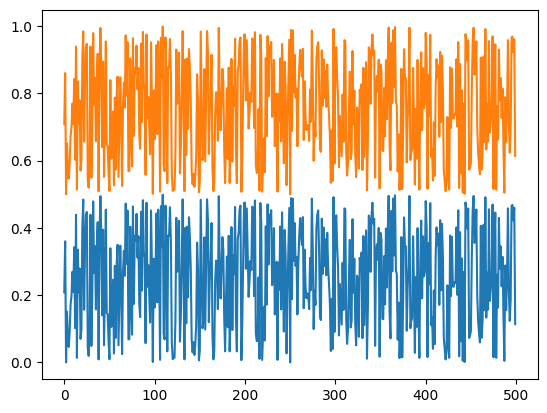

In [ ]:
plt.plot(u1)
plt.plot(u2)

In [ ]:
x = np.linspace(-np.pi/2,3*np.pi/2,10000)
f = bimodal_gaussian(x,0.50,0.6)
T2 = bimodal_gaussian_dist(N,0.50,0.6,seed=None)
T1 = np.r_[np.zeros(int((1/2 + eta1/2)*N)),np.pi* np.ones(N - int((1/2 + eta1/2)*N))]
Theta =  np.r_[T1,T2]

plt.plot(x,f)
plt.twinx()
plt.xlim(-np.pi/2,3*np.pi/2)
plt.hist(T2,bins=100,density=True)
plt.show()

0.0


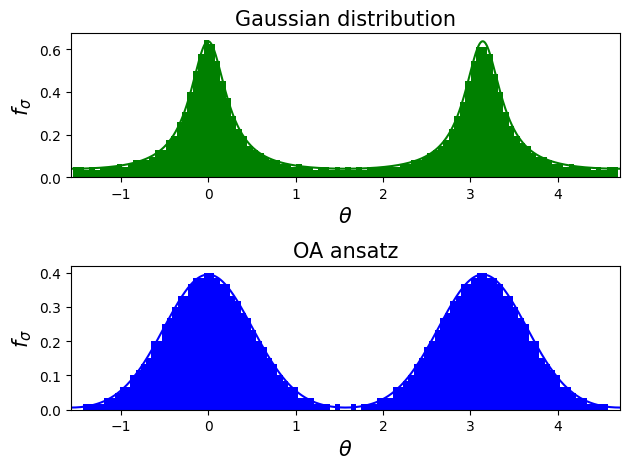

In [32]:
x = np.linspace(-np.pi/2,3*np.pi/2,10000)
f = bimodal_gaussian(x,0.50,0.6)
f_OA = dist_ab(x,-np.sqrt(0.6),np.sqrt(0.6),eta=0)
T2 = bimodal_gaussian_dist(N,0.50,0.6,seed=None)



T2_OA = gen_dist(N,a2,b2,eta2)
plt.subplot(212)

plt.plot(x,f,color='blue')
plt.xlim(-np.pi/2,3*np.pi/2)
plt.hist(T2,bins=100,density=True,facecolor='blue')
plt.xlabel(r'$\theta$',fontsize=15)
plt.ylabel(r'$f_\sigma$',fontsize=15)
plt.title(r'OA ansatz',fontsize=15)
plt.subplot(211)
plt.plot(x,f_OA,color='green')
plt.hist(T2_OA,bins=100,density=True,facecolor='green')
plt.xlim(-np.pi/2,3*np.pi/2)
plt.xlabel(r'$\theta$',fontsize=15)
plt.ylabel(r'$f_\sigma$',fontsize=15)
plt.title(r'Gaussian distribution',fontsize=15)

plt.tight_layout()


In [49]:
np.abs(np.mean(np.exp(2j*T2)))

0.6015994886127365

In [50]:
alpha = 0.2
beta = 0.2
eta1 = 0.1
eta2 = 0.0
shift = 0
N = 1000
Q1 = 1
Q2 = 0.6
t_end = 20_001
t = np.arange(0,t_end,0.1)

In [51]:
N1,N2 = N,N
K = 1
alphas = np.linspace(0,np.pi/2,31)[:-1]
betas = np.linspace(0,1,30)


R1s = []
R2s = []
Q1s = []
Q2s = []

for beta in tqdm(betas[:]):

    @parfor(alphas,args=(beta,),bar=False,n_processes=50)
    def ParFOR(alpha,beta):
        (Z1as,Z1bs,Z2as,Z2bs) = RK4_ZZ2(Kuramoto_MF_CHIMERA,Theta.copy(),t,args=(N1,N2,beta,alpha,K))
        R1 = np.abs(Z1as)[::100]
        R2 = np.abs(Z1bs)[::100]
        Q1 = np.abs(Z2as)[::100]
        Q2 = np.abs(Z2bs)[::100]
        
        return R1,R2,Q1,Q2
    R1,R2,Q1,Q2 = zip(*ParFOR)

    np.savez(f'SIMUL_gaussain/beta = {beta} N = {N}',Q1=Q1,Q2=Q2,R1=R1,R2=R2)

  0%|          | 0/30 [00:00<?, ?it/s]

In [52]:
A =  np.load(f'SIMUL_gaussain/beta = {beta} N = {N}.npz')

In [53]:
Q1s = np.zeros((30,30,len(A['Q1'][0]))) # BASIC 50,50
Q2s = np.zeros((30,30,len(A['Q2'][0]))) # BASIC 50,50
R1s = np.zeros((30,30,len(A['R1'][0]))) # BASIC 50,50
R2s = np.zeros((30,30,len(A['R2'][0]))) # BASIC 50,50
for i,beta in enumerate(betas):
    A =  np.load(f'SIMUL_gaussain/beta = {beta} N = {N}.npz')
    Q1s[i,:,:] = A['Q1']
    Q2s[i,:,:] = A['Q2']
    R2s[i,:,:] = A['R2']
    R1s[i,:,:] = A['R1']

In [28]:
eta1/eta2

ZeroDivisionError: float division by zero

In [54]:
np.savez(f'N = {N} Simulation result eta = infinity gaussian regular',Q1=Q1s,Q2=Q2s,R1=R1s,R2=R2s,beta=betas,alpha=alphas,t=t[::100])

In [55]:
t_temp = t[::100]
len(t_temp)

2001

In [56]:
from scipy.optimize import minimize_scalar 

In [36]:
# φ는 주어진 0 ~ 2π 범위를 그대로 쓰고,
phi = np.linspace(0, 2*np.pi, 10_000)

# α는 원하는 해상도로 – 여기선 0 ~ π/2 (끝점 제외) 500 점
AL = np.linspace(0, np.pi/2, 501)[:-1]
eta = eta1/eta2

def get_r_1_mup(alpha,phi,eta = 100):
    mu2 = eta**2*np.sin(alpha + 2*phi) - np.sin(alpha - 2*phi)
    mu1 = 2*eta*np.sin(phi)*np.cos(alpha)
    mu0 = (1 - eta**2)*np.sin(alpha)
    mu = (-mu1 + np.sqrt(mu1**2 - mu2*mu0))/mu2
    return mu
def get_mu_min(alphas,eta=100):
    mu_min = []

    for a in alphas:
        # ① 값 계산
        mu_vals = get_r_1_mup(a, phi, eta=eta)

        # ② 불연속·무의미(음수/1 초과/NaN) 구간 제거
        mask = np.isfinite(mu_vals) & (0 <= mu_vals) & (mu_vals <= 1)
        if not mask.any():          # 유효 구간이 전혀 없으면 NaN으로 채움
            mu_min.append(np.nan)
            continue

        # ③ 격자 상 최소값과 대응 φ
        idx = np.argmin(mu_vals[mask])
        mu_star = mu_vals[mask][idx]
        phi_star = phi[mask][idx]

        # ④ (선택) 최소 위치 근방을 SciPy로 미세 보정
        try:
            res = minimize_scalar(
                lambda x: get_r_1_mup(a, x, eta=eta),
                bounds=(max(phi_star-0.002, 0), min(phi_star+0.002, 2*np.pi)),
                method='bounded'
            )
            if res.success and 0 <= res.fun <= 1:
                mu_star = res.fun
        except Exception:
            pass        # SciPy가 없는 경우 그냥 격자값 사용

        mu_min.append(mu_star)

    mu_min = np.array(mu_min)
    return mu_min

ZeroDivisionError: float division by zero

C:\Users\kim9y\AppData\Local\Temp\ipykernel_42972\4095018199.py:12: RuntimeWarning: invalid value encountered in divide
  mu = (-mu1 + np.sqrt(mu1**2 - mu2*mu0))/mu2
C:\Users\kim9y\AppData\Local\Temp\ipykernel_42972\4095018199.py:12: RuntimeWarning: invalid value encountered in sqrt
  mu = (-mu1 + np.sqrt(mu1**2 - mu2*mu0))/mu2


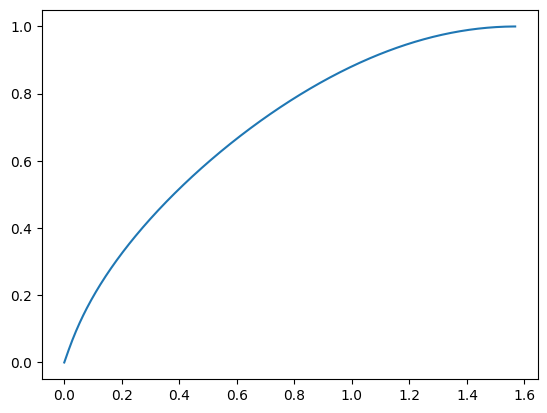

In [20]:
mu_min = get_mu_min(AL,eta=eta)
plt.plot(AL, mu_min,label=f'$\eta={eta}$')

(0.0, 1.0)

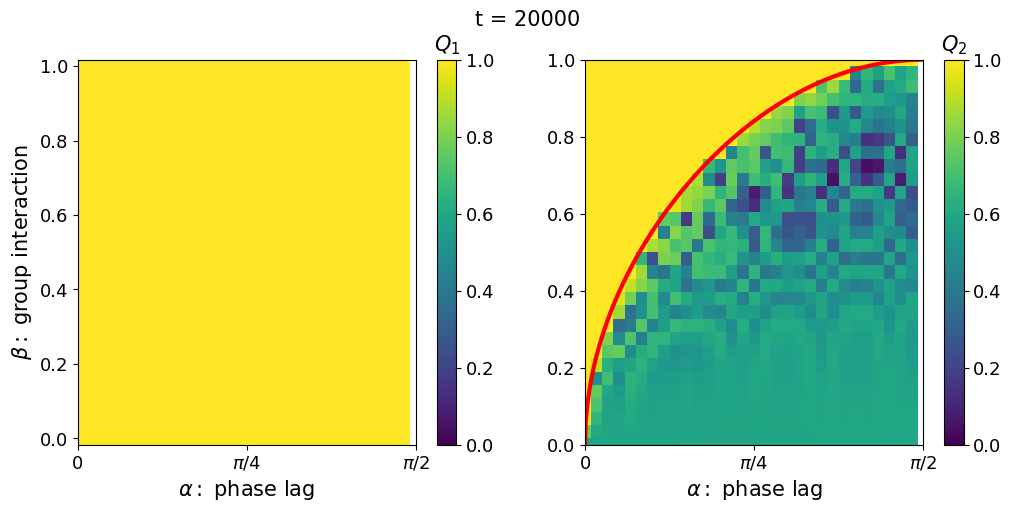

In [60]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,5),dpi=100)

index = -1
im1 = ax1.pcolormesh(alphas,betas,Q1s[:,:,index],vmin=0.0, vmax=1)
ax1.set_aspect('auto')
cbar1 = fig.colorbar(im1,ax=ax1,shrink=1)
cbar1.ax.set_title(r'$Q_1$',fontsize=15)
cbar1.ax.tick_params(labelsize=13)
plt.sca(ax1)
plt.xlabel(r'$\alpha:$ phase lag',fontsize = 15)
plt.ylabel(r'$\beta:$ group interaction',fontsize = 15)
plt.xlim(0,np.pi/2)
plt.xticks([0,np.pi/4,np.pi/2],[0,'$\pi/4$','$\pi/2$'],fontsize=13)
plt.yticks(fontsize=13)


im2 = ax2.pcolormesh(alphas,betas,Q2s[:,:,index],vmin=0.0, vmax=1)
ax2.set_aspect('auto')
ax2.plot(AL,np.sqrt(np.sin(AL)),color='red',lw=3)
# ax2.plot(AL, mu_min,label=f'$\eta={eta}$',color='k',lw=3)

ax2.plot()


cbar2 = fig.colorbar(im2,ax=ax2,shrink=1)
cbar2.ax.tick_params(labelsize=13)
cbar2.ax.set_title(r'$Q_2$',fontsize=15)

text = fig.suptitle(rf't = {t_temp[index] :.0f}',fontsize=15)
plt.sca(ax2)
plt.xlabel(r'$\alpha:$ phase lag',fontsize = 15)
plt.xlim(0,np.pi/2)
plt.xticks([0,np.pi/4,np.pi/2],[0,'$\pi/4$','$\pi/2$'],fontsize=13)
plt.yticks(fontsize=13);
plt.ylim(betas[0],1)



In [ ]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,5),dpi=100)

index = -1
im1 = ax1.pcolormesh(alphas,betas,Q1s[:,:,index],vmin=0.0, vmax=1)
ax1.set_aspect('auto')
cbar1 = fig.colorbar(im1,ax=ax1,shrink=1)
cbar1.ax.set_title(r'$Q_1$',fontsize=15)
cbar1.ax.tick_params(labelsize=13)
plt.sca(ax1)
plt.xlabel(r'$\alpha:$ phase lag',fontsize = 15)
plt.ylabel(r'$\beta:$ group interaction',fontsize = 15)
plt.xticks([0,np.pi/4,np.pi/2],[0,'$\pi/4$','$\pi/2$'],fontsize=13)
plt.yticks(fontsize=13)


im2 = ax2.pcolormesh(alphas,betas,Q2s[:,:,index],vmin=0.0, vmax=1)
ax2.set_aspect('auto')
ax2.plot(AL,np.sqrt(np.sin(AL)),color='red',lw=3)
ax2.plot(AL, mu_min,label=f'$\eta={eta}$',color='k',lw=3)

ax2.plot()


cbar2 = fig.colorbar(im2,ax=ax2,shrink=1)
cbar2.ax.tick_params(labelsize=13)
cbar2.ax.set_title(r'$Q_2$',fontsize=15)

text = fig.suptitle(rf't = {t_temp[index] :.0f}',fontsize=15)
plt.sca(ax2)
plt.xlabel(r'$\alpha:$ phase lag',fontsize = 15)
plt.xticks([0,np.pi/4,np.pi/2],[0,'$\pi/4$','$\pi/2$'],fontsize=13)
plt.yticks(fontsize=13);
plt.ylim(betas[0],1)



In [61]:
def get_ani(idx):
    im1.set_array(Q1s[:,:,idx])
    im2.set_array(Q2s[:,:,idx])
    text.set_text(rf't = ${t_temp[idx] :.0f}$')

len(t)
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 2**128
%config InlineBackend.figure_format = 'retina'
idxs=  np.arange(000,2001,10)
ani = FuncAnimation(fig,get_ani,frames=idxs,interval=50)
len(t)
# HTML(ani.to_jshtml())
ani.save(rf'HIGH ORDER CHIMERA/Gaussian Simulation  Q1 Q2 N = {N} Q2,eta1 = {eta1},eta2 = {eta2},shift = {shift/np.pi}pi,Q2_init = 0.1.mp4',dpi=300)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0')])

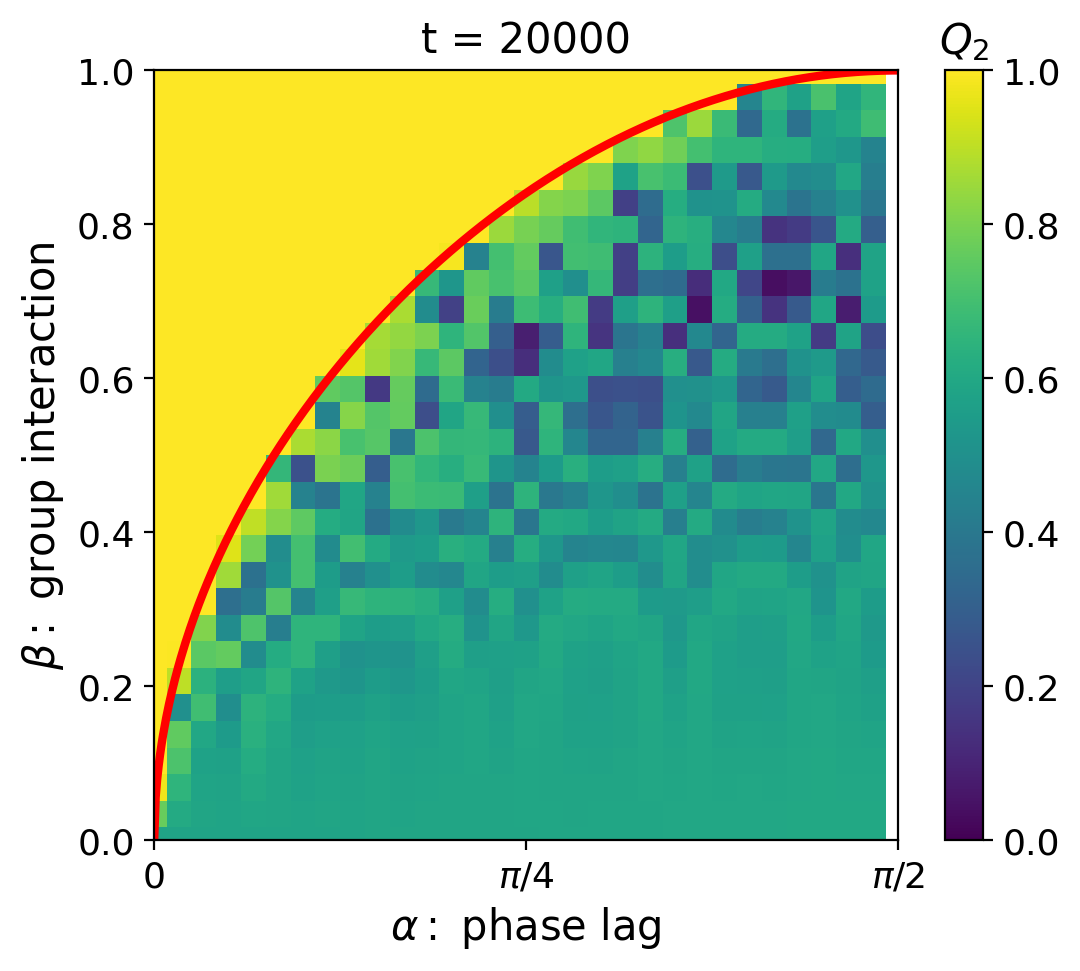

In [63]:
fig,(ax1) = plt.subplots(1,1,figsize=(6,5),dpi=100)

index = -1
im1 = ax1.pcolormesh(alphas,betas,Q2s[:,:,index],vmin=0.0, vmax=1)
ax1.set_aspect('auto')
text = ax1.set_title(rf't = {t_temp[index] :.0f}',fontsize=15)
ax1.plot(AL,np.sqrt(np.sin(AL)),color='red',lw=3)
# ax1.plot(AL, mu_min,label=f'$\eta={eta}$',color='k',lw=3)
cbar1 = fig.colorbar(im1,ax=ax1,shrink=1)
cbar1.ax.set_title(r'$Q_2$',fontsize=15)
cbar1.ax.tick_params(labelsize=13)
plt.sca(ax1)
plt.ylim(betas[0],1)
plt.xlim(0,np.pi/2)
plt.xlabel(r'$\alpha:$ phase lag',fontsize = 15)
plt.ylabel(r'$\beta:$ group interaction',fontsize = 15)
plt.xticks([0,np.pi/4,np.pi/2],[0,'$\pi/4$','$\pi/2$'],fontsize=13)
plt.yticks(fontsize=13)


In [65]:
def get_ani(idx):
    im1.set_array(Q2s[:,:,idx])
    text.set_text(rf't = ${t_temp[idx] :.0f}$')

len(t)
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 2**128
%config InlineBackend.figure_format = 'retina'
idxs=  np.arange(000,2001,10)
ani = FuncAnimation(fig,get_ani,frames=idxs,interval=50)
len(t)
# HTML(ani.to_jshtml())
ani.save(rf'HIGH ORDER CHIMERA/Gaussian Simulation Q2 N = {N} Q2,eta1 = {eta1},eta2 = {eta2},shift = {shift/np.pi}pi,Q2_init = 0.1.mp4',dpi=300)

In [27]:
from Simul import get_RQ_MOA4,get_RQ_MOA5,get_RQ_MOA2,get_R_simul_wfT
import numpy as np
import matplotlib.pyplot as plt

In [31]:
N =10000

In [32]:
N1,N2 = N,N
K = 1
alphas = np.linspace(0,np.pi/2,100)
betas = np.linspace(0,1,101)[1:]

In [58]:
N1,N2 = N,N
K = 1
alphas = np.linspace(0,np.pi/2,100)
betas = np.linspace(0,1,101)[1:]

Q_init = 0.6
for beta in tqdm(betas[20:]):

    @parfor(alphas,args=(beta,),bar=False)
    def ParFOR(alpha,beta):
        Z1as,Z1bs,Z2as,Z2bs,t = get_RQ_MOA4(1,Q_init,alpha=alpha,beta=beta,eta1=eta1,eta2=eta2,shift=shift,t_end=t_end,dt=0.1)
        R1 = np.abs(Z1as)[::100]
        R2 = np.abs(Z1bs)[::100]
        Q1 = np.abs(Z2as)[::100]
        Q2 = np.abs(Z2bs)[::100]
        
        return R1,R2,Q1,Q2
    R1,R2,Q1,Q2 = zip(*ParFOR)

    np.savez(f'SIMUL OA/beta = {beta} N = {N}',Q1=Q1,Q2=Q2,R1=R1,R2=R2)




  0%|          | 0/80 [00:00<?, ?it/s]

In [33]:
Q1s = np.zeros((100,100,len(A['Q1'][0])))
Q2s = np.zeros((100,100,len(A['Q2'][0])))
R1s = np.zeros((100,100,len(A['R1'][0])))
R2s = np.zeros((100,100,len(A['R2'][0])))
for i,beta in enumerate(betas):
    A =  np.load(f'SIMUL OA/beta = {beta} N = {N}.npz')
    Q1s[i,:,:] = A['Q1']
    Q2s[i,:,:] = A['Q2']
    R2s[i,:,:] = A['R2']
    R1s[i,:,:] = A['R1']

NameError: name 'A' is not defined

In [34]:
A =  np.load(f'SIMUL OA/beta = {beta} N = {N}.npz')

NameError: name 'beta' is not defined

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0')])

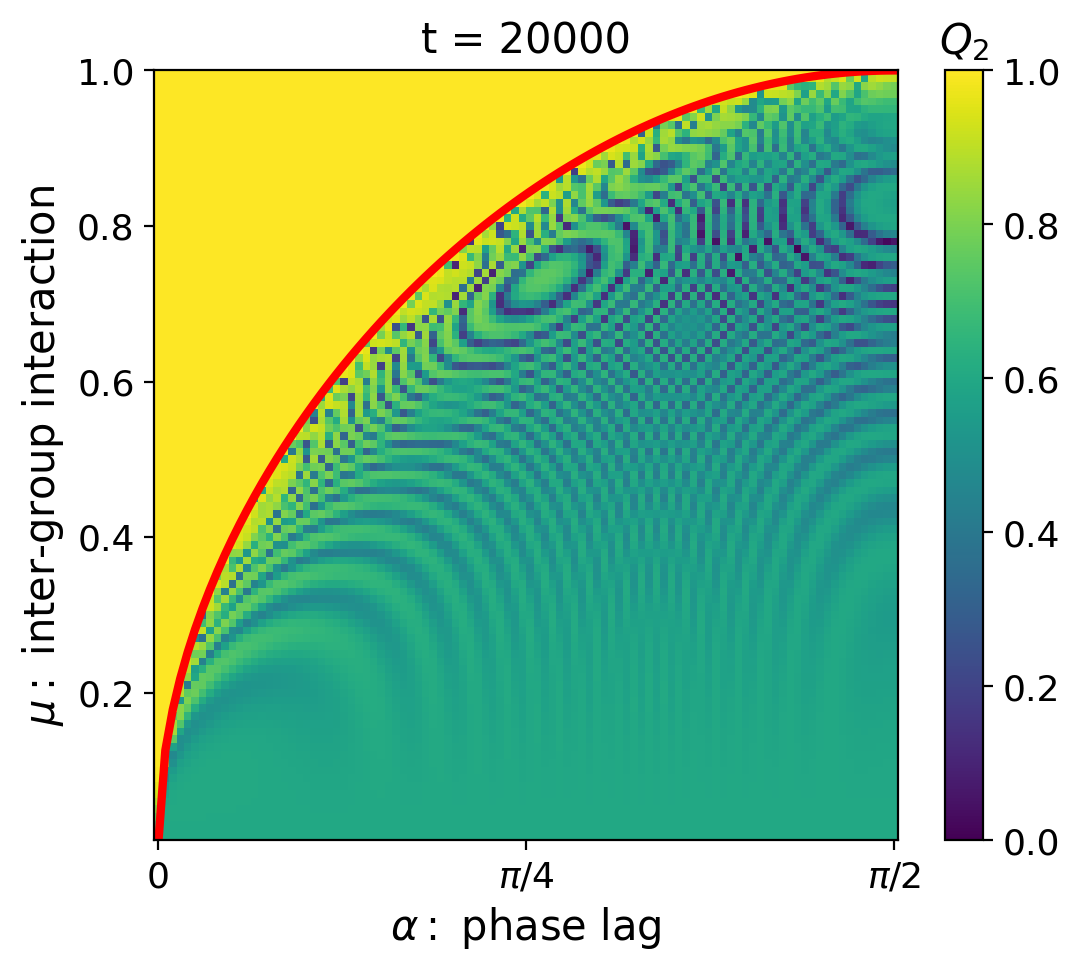

In [63]:
fig,(ax1) = plt.subplots(1,1,figsize=(6,5),dpi=100)

index = -1
im1 = ax1.pcolormesh(alphas,betas,Q2s[:,:,index],vmin=0.0, vmax=1)
ax1.set_aspect('auto')
text = ax1.set_title(rf't = {t_temp[index] :.0f}',fontsize=15)

cbar1 = fig.colorbar(im1,ax=ax1,shrink=1)
cbar1.ax.set_title(r'$Q_2$',fontsize=15)
cbar1.ax.tick_params(labelsize=13)
plt.sca(ax1)
ax1.plot(alphas,np.sqrt(np.sin(alphas)),color='red',lw=3)

plt.xlabel(r'$\alpha:$ phase lag',fontsize = 15)
plt.ylim(betas[0],1)
plt.ylabel(r'$\mu:$ inter-group interaction',fontsize = 15)
plt.xticks([0,np.pi/4,np.pi/2],[0,'$\pi/4$','$\pi/2$'],fontsize=13)
plt.yticks(fontsize=13)


(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0')])

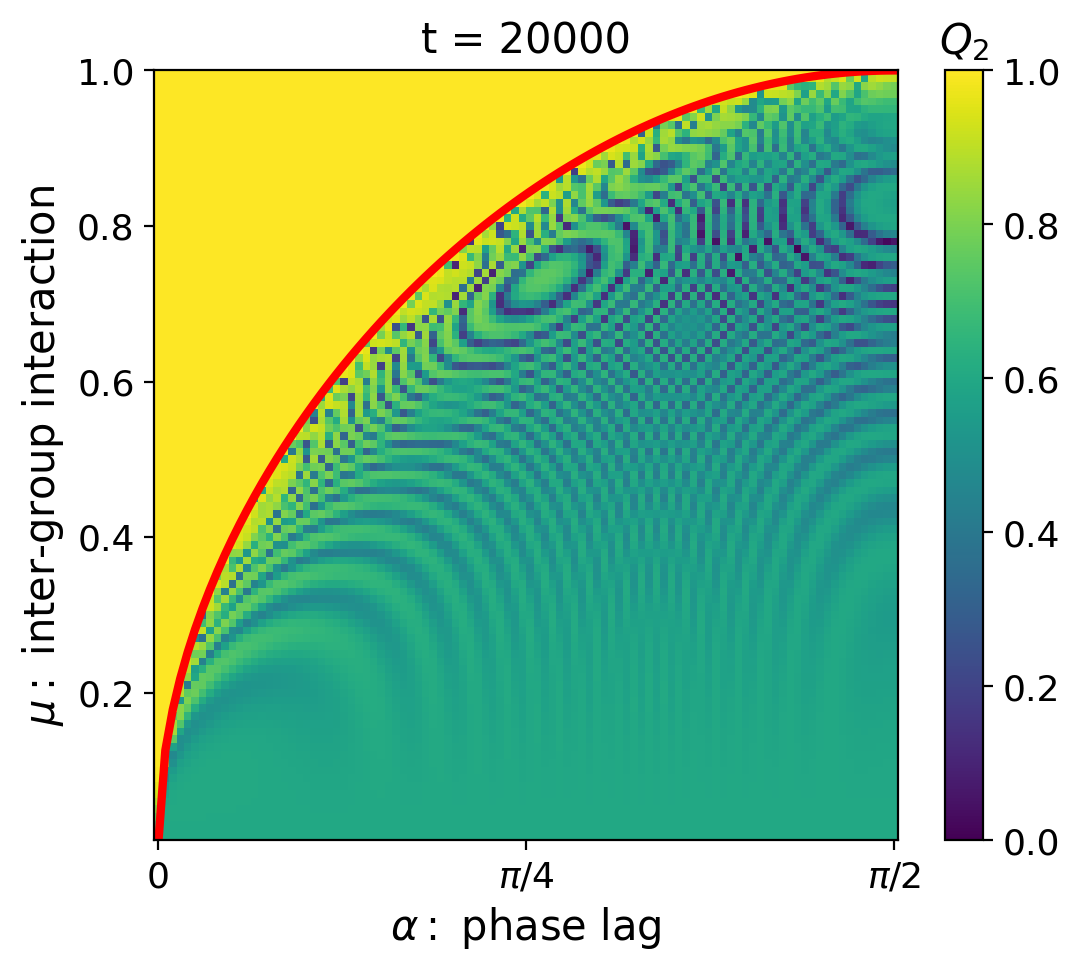

In [69]:
fig,(ax1) = plt.subplots(1,1,figsize=(6,5),dpi=100)

index = -1
im1 = ax1.pcolormesh(alphas,betas,Q2s[:,:,index],vmin=0.0, vmax=1)
ax1.set_aspect('auto')
text = ax1.set_title(rf't = {t_temp[index] :.0f}',fontsize=15)

cbar1 = fig.colorbar(im1,ax=ax1,shrink=1)
cbar1.ax.set_title(r'$Q_2$',fontsize=15)
cbar1.ax.tick_params(labelsize=13)
plt.sca(ax1)
ax1.plot(alphas,np.sqrt(np.sin(alphas)),color='red',lw=3)

plt.xlabel(r'$\alpha:$ phase lag',fontsize = 15)
plt.ylim(betas[0],1)
plt.ylabel(r'$\mu:$ inter-group interaction',fontsize = 15)
plt.xticks([0,np.pi/4,np.pi/2],[0,'$\pi/4$','$\pi/2$'],fontsize=13)
plt.yticks(fontsize=13)


In [61]:
def get_ani(idx):
    im1.set_array(Q2s[:,:,idx])
    text.set_text(rf't = ${t_temp[idx] :.0f}$')

len(t)
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 2**128
%config InlineBackend.figure_format = 'retina'
idxs=  np.arange(000,2001,10)
ani = FuncAnimation(fig,get_ani,frames=idxs,interval=50)
len(t)
# HTML(ani.to_jshtml())
ani.save(rf'HIGH ORDER CHIMERA/OA Q1 Q2, eta1 = {eta1},eta2 = {eta2},shift = {shift/np.pi}pi,Q2_init = 0.6.mp4',dpi=300)

In [92]:
alpha = 0.2
beta = 0.8
Z1as,Z1bs,Z2as,Z2bs,t = get_RQ_MOA4(1,Q_init,alpha=alpha,beta=beta,eta1=eta1,eta2=eta2,shift=shift,t_end=t_end,dt=0.1)
R1 = np.abs(Z1as)
R2 = np.abs(Z1bs)
Q1 = np.abs(Z2as)
Q2 = np.abs(Z2bs)

In [93]:
(Z1as,Z1bs,Z2as,Z2bs) = RK4_ZZ2(Kuramoto_MF_CHIMERA,Theta.copy(),t,args=(N1,N2,beta,alpha,K))
R1_sim = np.abs(Z1as)
R2_sim = np.abs(Z1bs)
Q1_sim = np.abs(Z2as)
Q2_sim = np.abs(Z2bs)

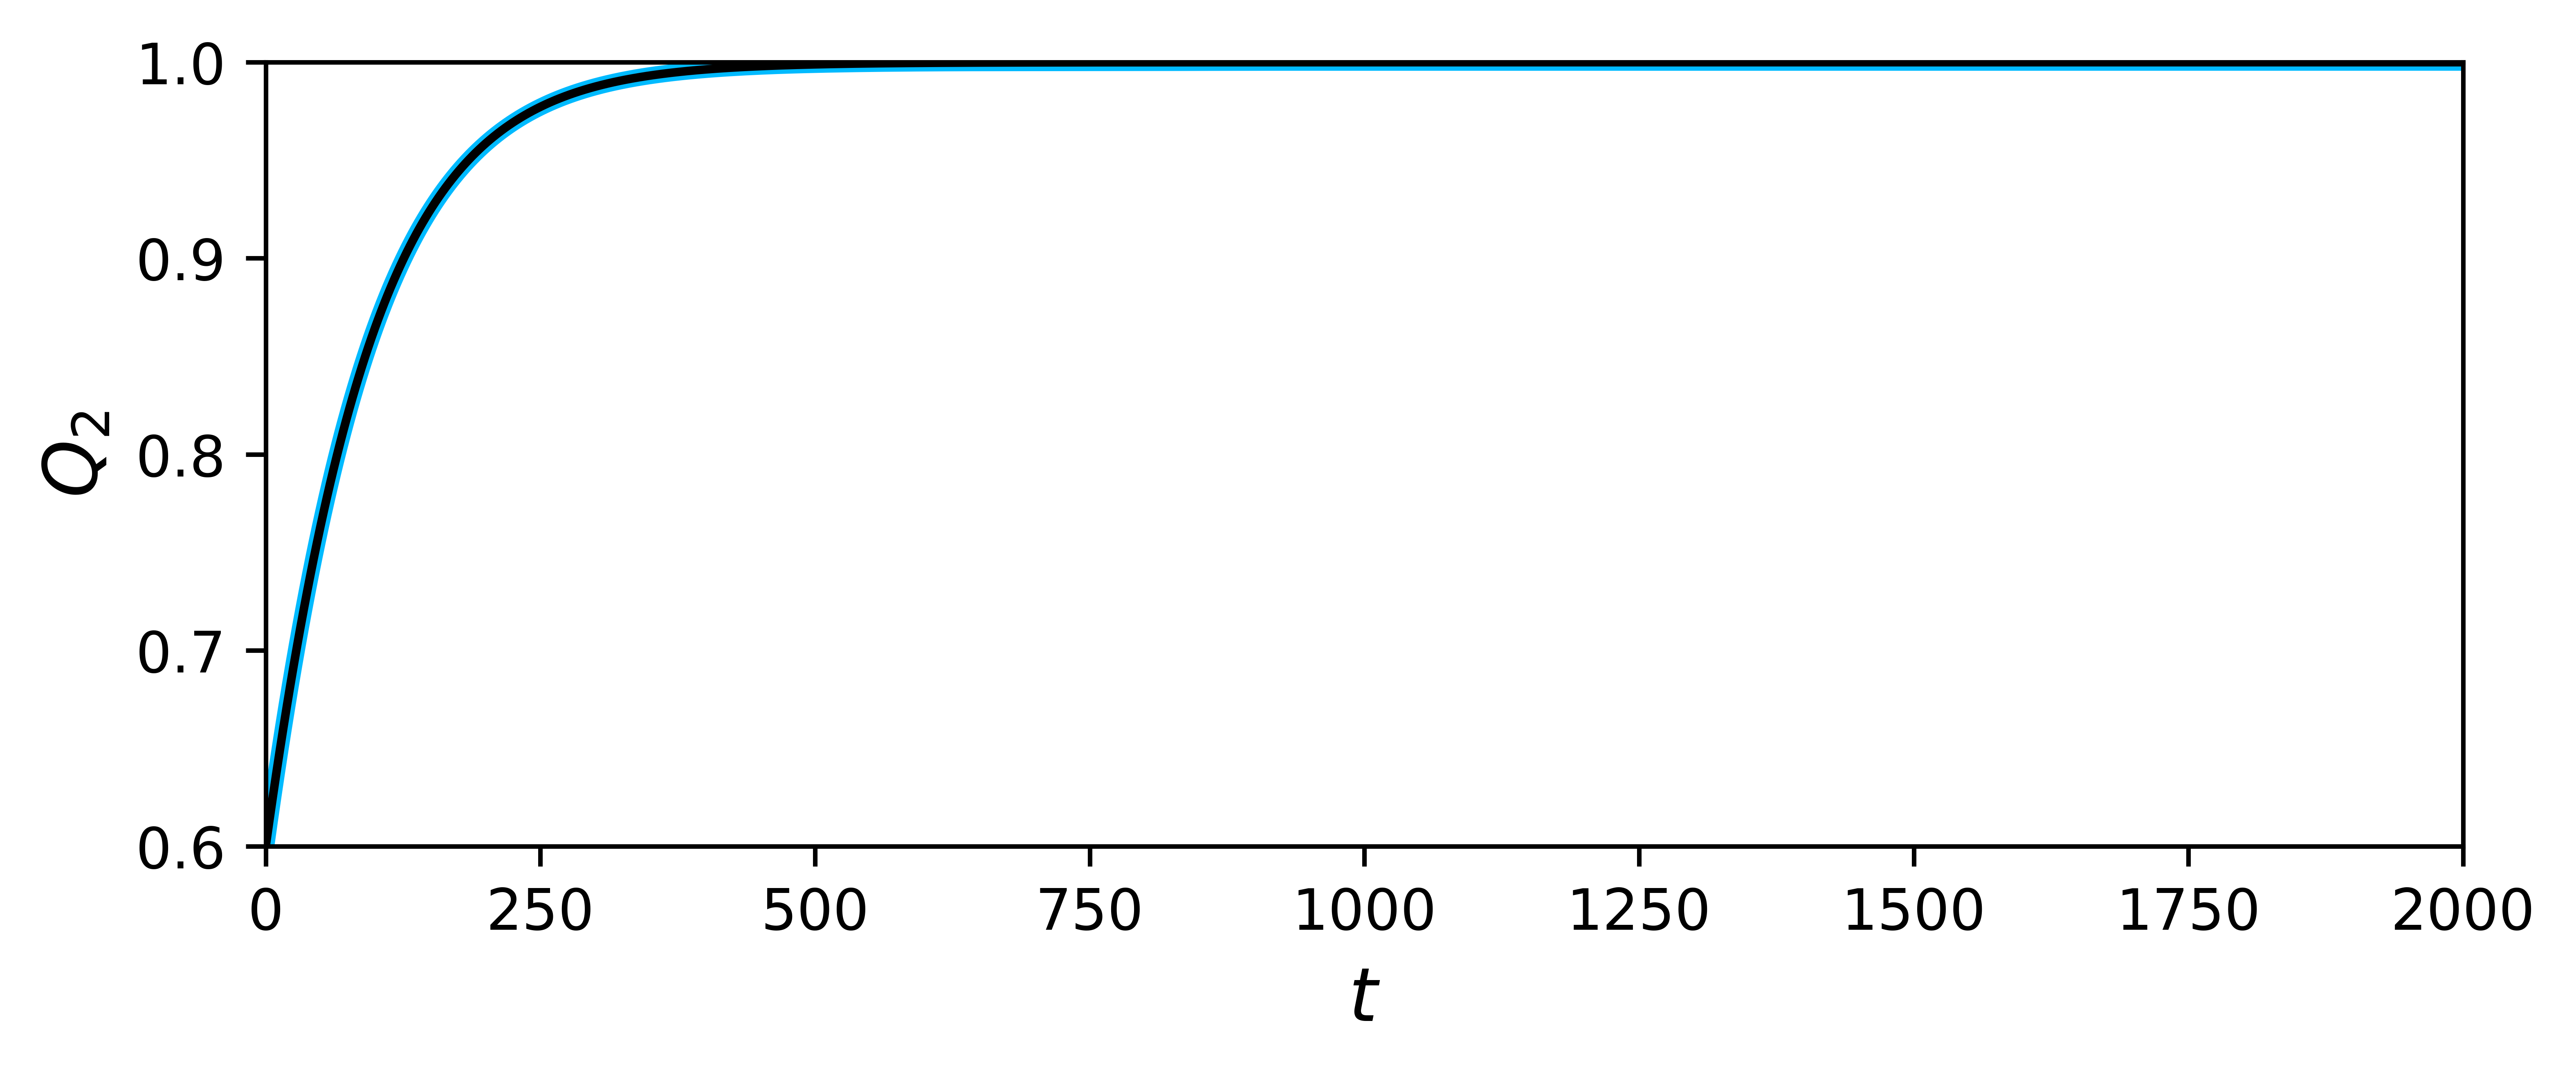

In [ ]:
plt.figure(dpi=500)
plt.subplot(211)
plt.plot(t,Q2_sim,color='#00BAFF',lw=3)
plt.plot(t,Q2,color='k')
plt.xlim(0,2000)
plt.ylim(0.6,1)
plt.xlabel(r'$t$',fontsize=13)
plt.ylabel(r'$Q_2$',fontsize=13)
plt.tight_layout()


In [ ]:
# Plot contours with specific colors and store the contour objects
c1 = plt.contour(np.mean(Rs[256][:,:,-100:],axis=(2)), levels=[0.15, 0.16], colors=['red', 'red'], 
                 extent=[etas[0],etas[-1],rhos[0],rhos[-1]])
c2 = plt.contour(np.mean(Rs[512][:,:,-100:],axis=(2)), levels=[0.15, 0.16], colors=['green', 'green'], 
                 extent=[etas[0],etas[-1],rhos[0],rhos[-1]])
c3 = plt.contour(np.mean(Rs[1024][:,:,-100:],axis=(2)), levels=[0.15, 0.16], colors=['blue', 'blue'], 
                 extent=[etas[0],etas[-1],rhos[0],rhos[-1]])

# Create proxy artists for the legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='red', label='Lx=256'),
                  Line2D([0], [0], color='green', label='Lx=512'),
                  Line2D([0], [0], color='blue', label='Lx=1024')]

plt.legend(handles=legend_elements)
plt.xlabel(r'$\eta$',fontsize=15)
plt.ylabel(r'$\rho$',fontsize=15)


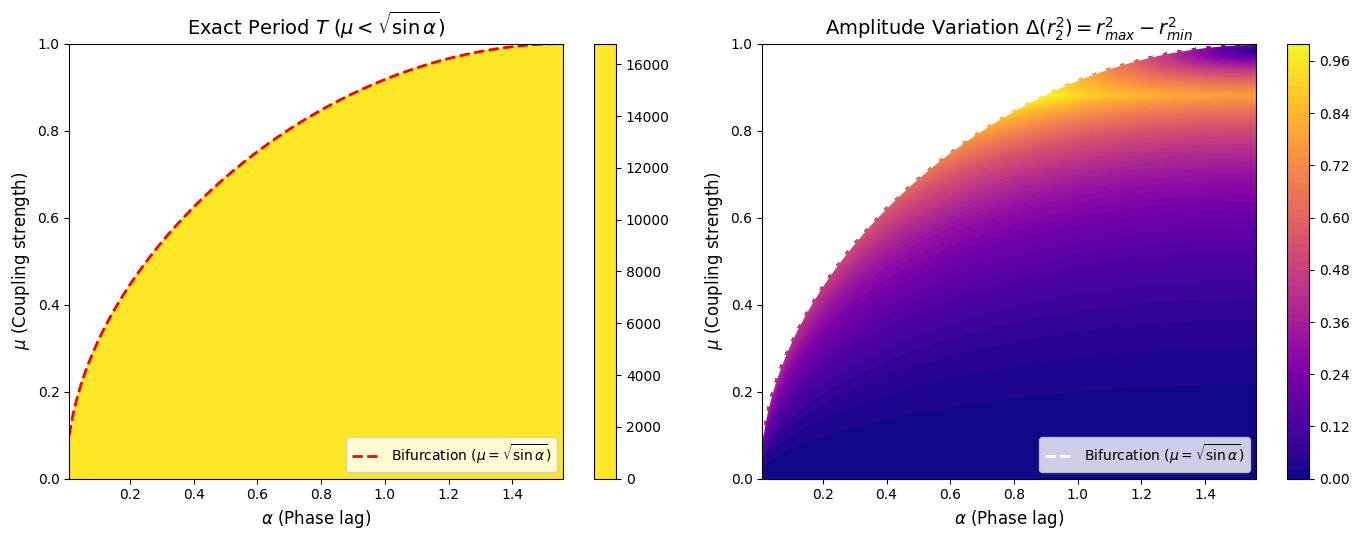

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 파라미터 공간 정의 (해상도 300x300)
alpha_vals = np.linspace(0.01, np.pi/2 - 0.01, 3000)
mu_vals = np.linspace(0.0, 1.0, 3000)
A_grid, M_grid = np.meshgrid(alpha_vals, mu_vals)

# 2. Limit cycle 존재 영역 마스킹 (mu < sqrt(sin(alpha)))
mask = M_grid**2 < np.sin(A_grid)

# 3. 정확한 주기(Period T) 연산
# 편의상 eta 관련 스케일러 (1-2eta')^2 = 1 로 둡니다.
Period = np.full_like(A_grid, np.nan)
Period[mask] = np.pi / np.sqrt(np.sin(A_grid[mask])**2 - M_grid[mask]**4)

# 4. 진폭 최대-최소 차이 (Delta r^2) 연산
r0_sq = np.sqrt(0.6)  # 논문 초기조건 a_2 = sqrt(0.6)
phi0 = 0   # 논문 초기 위상
theta0 = 2 * phi0 + A_grid[mask]

# 보존량 C0 계산
C0 = (np.sin(A_grid[mask]) - (M_grid[mask]**2) * r0_sq * np.sin(theta0)) / (1 - r0_sq**2)

# 기하학적 중심거리(|Z_c|) 및 반지름(R) 연산
Zc_mag = M_grid[mask]**2 / (2 * np.abs(C0))
R_sq = 1 - np.sin(A_grid[mask])/C0 + (M_grid[mask]**4)/(4 * C0**2)
R = np.sqrt(np.maximum(R_sq, 0)) # 근호 안 미세 음수 오차 방지

Delta_r2 = np.full_like(A_grid, np.nan)
# Delta = (Max) - (Min) = (|Z_c| + R) - | |Z_c| - R |
Delta_r2[mask] = (Zc_mag + R) - np.abs(Zc_mag - R)

# 5. 시각화 (Plotting)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (1) Period T Plot
c1 = axes[0].contourf(A_grid, M_grid, Period, levels=50, cmap='viridis', vmax=30)
axes[0].plot(alpha_vals, np.sqrt(np.sin(alpha_vals)), 'r--', lw=2, label=r'Bifurcation ($\mu = \sqrt{\sin\alpha}$)')
axes[0].set_title(r'Exact Period $T$ ($\mu < \sqrt{\sin\alpha}$)', fontsize=14)
axes[0].set_xlabel(r'$\alpha$ (Phase lag)', fontsize=12)
axes[0].set_ylabel(r'$\mu$ (Coupling strength)', fontsize=12)
axes[0].legend(loc='lower right')
fig.colorbar(c1, ax=axes[0])

# (2) Delta r^2 Plot
c2 = axes[1].contourf(A_grid, M_grid, Delta_r2, levels=50, cmap='plasma')
axes[1].plot(alpha_vals, np.sqrt(np.sin(alpha_vals)), 'w--', lw=2, label=r'Bifurcation ($\mu = \sqrt{\sin\alpha}$)')
axes[1].set_title(r'Amplitude Variation $\Delta(r_2^2) = r_{max}^2 - r_{min}^2$', fontsize=14)
axes[1].set_xlabel(r'$\alpha$ (Phase lag)', fontsize=12)
axes[1].set_ylabel(r'$\mu$ (Coupling strength)', fontsize=12)
axes[1].legend(loc='lower right')
fig.colorbar(c2, ax=axes[1])

plt.tight_layout()
plt.show()

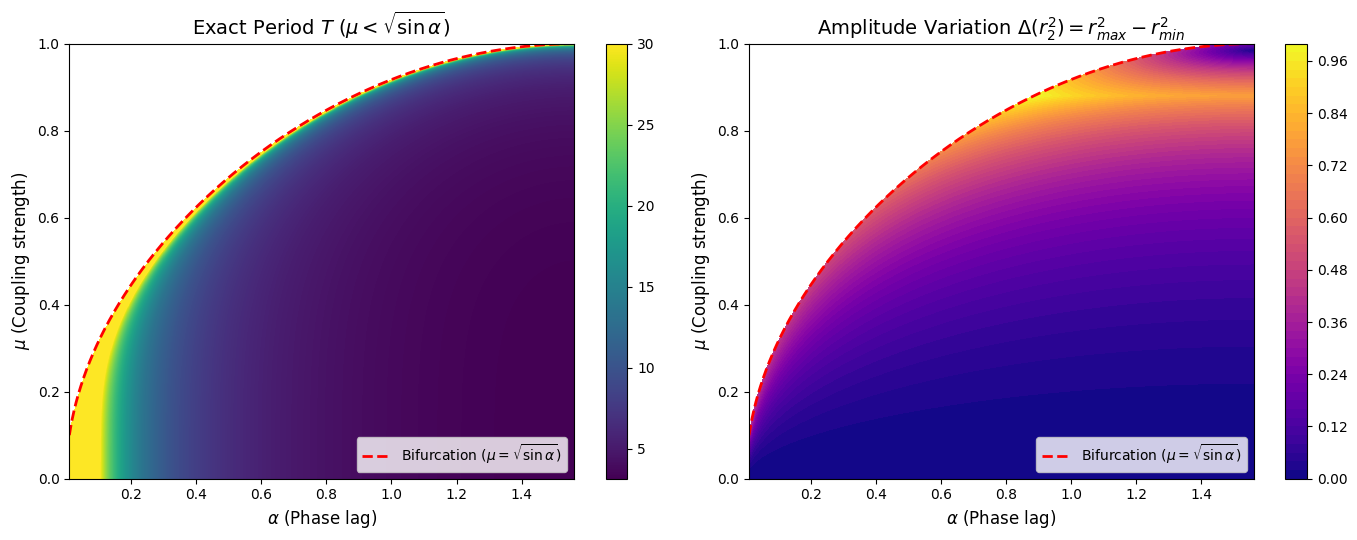

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (1) Period T Plot
c1 = axes[0].pcolormesh(A_grid, M_grid, Period,vmax=30, cmap='viridis')
axes[0].plot(alpha_vals, np.sqrt(np.sin(alpha_vals)), 'r--', lw=2, label=r'Bifurcation ($\mu = \sqrt{\sin\alpha}$)')
axes[0].set_title(r'Exact Period $T$ ($\mu < \sqrt{\sin\alpha}$)', fontsize=14)
axes[0].set_xlabel(r'$\alpha$ (Phase lag)', fontsize=12)
axes[0].set_ylabel(r'$\mu$ (Coupling strength)', fontsize=12)
axes[0].legend(loc='lower right')
fig.colorbar(c1, ax=axes[0])

# (2) Delta r^2 Plot
c2 = axes[1].contourf(A_grid, M_grid, Delta_r2, levels=50, cmap='plasma')
axes[1].plot(alpha_vals, np.sqrt(np.sin(alpha_vals)), 'r--', lw=2, label=r'Bifurcation ($\mu = \sqrt{\sin\alpha}$)')
axes[1].set_title(r'Amplitude Variation $\Delta(r_2^2) = r_{max}^2 - r_{min}^2$', fontsize=14)
axes[1].set_xlabel(r'$\alpha$ (Phase lag)', fontsize=12)
axes[1].set_ylabel(r'$\mu$ (Coupling strength)', fontsize=12)
axes[1].legend(loc='lower right')
fig.colorbar(c2, ax=axes[1])

plt.tight_layout()
plt.show()

In [35]:
Z1as,Z1bs,Z2as,Z2bs,t = get_RQ_MOA4(1,Q_init,alpha=alpha,beta=beta,eta1=eta1,eta2=eta2,shift=shift,t_end=t_end,dt=0.1)
R1 = np.abs(Z1as)[::100]
R2 = np.abs(Z1bs)[::100]
Q1 = np.abs(Z2as)[::100]
Q2 = np.abs(Z2bs)[::100]

NameError: name 'Q_init' is not defined

In [37]:
Q_init = 0.6

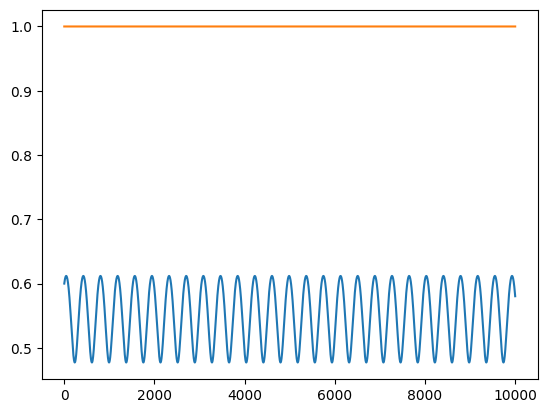

In [67]:
alpha = 1
beta = 0.4
eta1=0.1
eta2=0.0
shift =0
t_end= 10000
Z1as,Z1bs,Z2as,Z2bs,t = get_RQ_MOA4(1,Q_init,alpha=alpha,beta=beta,eta1=eta1,eta2=eta2,shift=shift,t_end=t_end,dt=0.1)
R1 = np.abs(Z1as)
R2 = np.abs(Z1bs)
Q1 = np.abs(Z2as)
Q2 = np.abs(Z2bs)
plt.plot(t,Q2)
plt.plot(t,Q1)

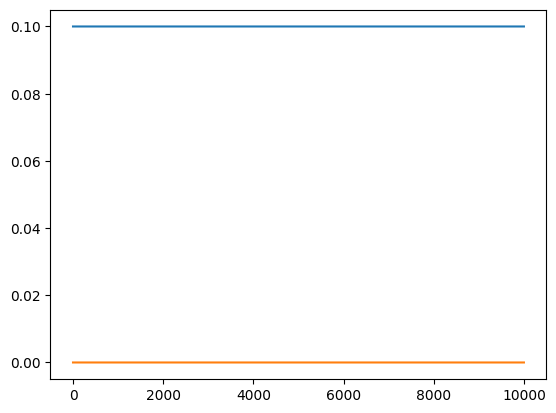

In [70]:
plt.plot(t,R1)
plt.plot(t,R2)

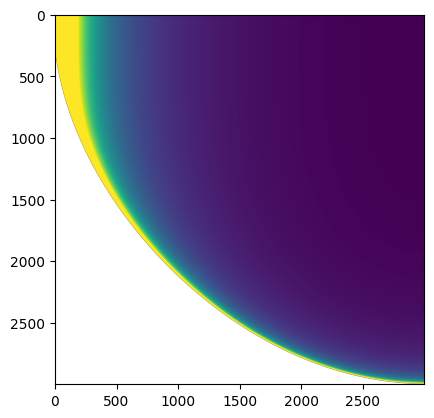

In [21]:
plt.imshow(Period,vmax=30)

In [ ]:
eta1 = 1 - 2*eta1

▶ 시뮬레이션 주기 (T_sim): 380.283333
▶ 이론적 주기 (T_theory): 424.356152
▶ 오차율: 10.385809 %


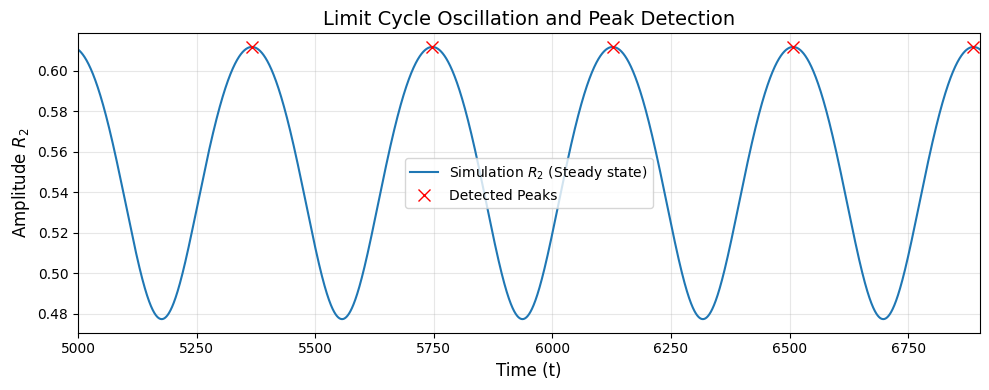

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- (질문자님의 이전 코드가 위에서 실행되었다고 가정: R1, t 등이 생성됨) ---

# 1. 시뮬레이션 데이터에서 주기(Period) 추출
# 초기 과도 응답(Transient state)을 제거하기 위해 후반부 50% 데이터만 사용
steady_idx = len(t) // 2
t_steady = t[steady_idx:]
R1_steady = Q2[steady_idx:]

# 진폭 데이터에서 피크(최댓값) 위치 찾기
peaks, _ = find_peaks(R1_steady)
peak_times = t_steady[peaks]

# 피크 간의 시간 간격들의 평균을 시뮬레이션 주기로 계산
if len(peak_times) > 1:
    simulated_period = np.mean(np.diff(peak_times))
    print(f"▶ 시뮬레이션 주기 (T_sim): {simulated_period:.6f}")
else:
    print("진동(Limit Cycle)이 없거나 피크를 충분히 찾지 못했습니다.")
    simulated_period = None

# 2. 이론적 주기(Period) 계산
# 이전 답변의 식: T = pi / sqrt(B^2 - A^2)
# (주의: 질문자님의 dZ4_dt 정의에 따라 beta가 mu^2 역할을 한다고 가정했습니다. 
# 만약 식 정의가 다르다면 A, B 식을 질문자님의 모델 파라미터에 맞게 수정해주세요.)
mu_sq = beta  
A_theory = mu_sq * (eta1)**2
B_theory = np.sin(alpha) * (eta1)**2

if B_theory**2 > A_theory**2:
    theoretical_period = np.pi / np.sqrt(B_theory**2 - A_theory**2)
    print(f"▶ 이론적 주기 (T_theory): {theoretical_period:.6f}")
    
    # 두 값의 오차율 계산
    if simulated_period:
        error_percent = abs(simulated_period - theoretical_period) / theoretical_period * 100
        print(f"▶ 오차율: {error_percent:.6f} %")
else:
    print("▶ 이론적 조건: 진동(Limit cycle) 영역이 아닙니다. (Fixed point 수렴 구간)")

# 3. 추출된 피크 시각화 확인
plt.figure(figsize=(10, 4))
plt.plot(t_steady, R1_steady, label='Simulation $R_2$ (Steady state)')
plt.plot(t_steady[peaks], R1_steady[peaks], "x", color='red', markersize=8, label='Detected Peaks')

# 주기를 시각적으로 확인하기 쉽도록 약 5주기 정도만 X축 확대
if simulated_period:
    plt.xlim(t_steady[0], t_steady[0] + simulated_period * 5)

plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Amplitude $R_2$', fontsize=12)
plt.title('Limit Cycle Oscillation and Peak Detection', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()